In [3]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
from jaxopt import ScipyBoundedMinimize
from jaxopt import LBFGSB
from jax import value_and_grad

print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
# import numpyro
# numpyro.set_platform("gpu")
# numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import copy
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
new_data = read_yaml(abs_path_params + '/xDESI/params_fit_abacus.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# # analysis_dict['beam_fwhm_arcmin'] = 1.4
# df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
# zarray_comoving = df_nz_comoving[:,0]
# nz_comoving_orig = df_nz_comoving[:,1]
# indsel = np.where(zarray_comoving < 0.4)[0]
# nz_comoving = np.zeros_like(zarray_comoving)
# nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
# indsel = np.where(zarray_comoving > 0.4)[0]
# nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
# analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
# analysis_dict['nbar_gal_comoving_val'] = nz_comoving

from scipy.interpolate import interp1d
# ks = np.geomspace(5e-2,50,15) # wavenumbers
ks = np.geomspace(3e-1,10,10) # wavenumbers
# zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 200)


cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)

# import asdf
# z_array = np.linspace(0, 1.5, 200)
# z_centers = 0.5 * (z_array[1:] + z_array[:-1])
df_sims = pk.load(open(os.path.abspath(abs_path_data + '/xDESI/abacus_LRG_nz_Clgg_v2.pkl'), 'rb'))

zvals = df_sims['zvals']
nbins_lens = len(zvals)
# zarray_lens_edges = 
delta_zarray = zarray_lens[1] - zarray_lens[0]
zarray_lens_edges = np.concatenate(([zarray_lens[0] - delta_zarray/2], 0.5*(zarray_lens[1:] + zarray_lens[:-1]), [zarray_lens[-1] + delta_zarray/2]))
# nz_comoving_all = np.zeros((len(zvals), len(zarray_lens)))
nz_lens = {}


# nbar_all = []
Ngals_bins = []
# for jz, zval in enumerate(zvals):
for jz, zval_group in enumerate(zvals):    
    # ldir = '/work/hdd/bdne/spandey3/abacus'
    
    # fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
    # f = asdf.open(fn)

    # gal_ra, gal_dec = f['data']['RA'], f['data']['DEC']
    # gal_z = f['data']['Z_COSMO']
    # Ngals_bins.append(len(gal_z))
    Ngals_jz = df_sims['Ngal_all'][f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}']
    Ngals_bins.append(Ngals_jz)
    # zmin = df_sims['zmin_all'][f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}']
    # zmax = df_sims['zmax_all'][f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}']
    # chi_min = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmin))
    # chi_max = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmax))

    # comoving_volume = (4.0/3.0) * np.pi * (chi_max**3 - chi_min**3) * (1/8.)
    # nbar = Ngals_jz / comoving_volume  # in (Mpc/h)^-3
    # nbar_all.append(nbar)

    zcen_nz_file = df_sims['nz_gal_all']['z_array']
    nz_gal_file = df_sims['nz_gal_all'][f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}']
    nz_gal_interp = interp1d(zcen_nz_file, nz_gal_file, fill_value=0.0, bounds_error=False)


    # hist_z = np.histogram(gal_z, bins=zarray_lens_edges, density=True)[0]
    hist_z = nz_gal_interp(zarray_lens)
    nz_lens[jz] = hist_z/( np.trapz(hist_z, zarray_lens) )

    nz_comoving = np.zeros_like(zarray_lens)
    indsel = np.where(hist_z > 1e-5)[0]
    # nz_comoving[indsel] = nbar
    # nz_comoving_all[jz] = nz_comoving

nbar_comoving_file = df_sims['nbar_comoving']
zcens_comoving_file = df_sims['zcens_comoving']

nbar_interp = interp1d(zcens_comoving_file, nbar_comoving_file, fill_value=1e-8, bounds_error=False)
nbar_array = nbar_interp(zarray_lens)


analysis_dict['nbar_gal_comoving_zarray'] = zarray_lens
# analysis_dict['nbar_gal_comoving_val'] = np.sum(np.array(nz_comoving_all), axis=0)
analysis_dict['nbar_gal_comoving_val'] = nbar_array

# chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
# dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
# nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
# nz_comoving_zarray = nz_comoving_interp(zarray_lens)
# nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
# nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
# nz_lens = {}
# for jb in range(nbins_lens):
#     nz_jb = np.zeros_like(nz_zarray)
#     indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
#     nz_jb[indsel] = nz_zarray[indsel]
#     norm_val = np.trapz(nz_jb, zarray_lens)
#     nz_jb = nz_jb/norm_val
#     nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 1
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

# Ngals_bins = []
# Vol_Gpc3 = []
# z_cens = []
# P0 = 9e3
# fsky_DESIxDESI = analysis_dict['fsky_gg']
# for jb in range(nbins_lens):
#     nz_jb_only = np.copy(nz_comoving_zarray)
#     indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
#     nz_jb_only[indsel] = 0.0
#     nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

#     ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
#     Ngals_bins.append(ntot_jb)

#     zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
#     z_cens.append(zmean)

#     fsky_nz = np.ones_like(zarray_lens)
#     fsky_nz[indsel] = 0.0
#     fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
#     h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
#     Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
#     Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   

#     Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
#     print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
#     # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
    

# Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
    
#     # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = np.array(Ngals_bins)/(0.125*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

# analysis_dict['symbolic_pk'] = False
# analysis_dict['symbolic_hmf'] = False




/tmp/ipykernel_2772546/3584092003.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_lens[jz] = hist_z/( np.trapz(hist_z, zarray_lens) )


Text(0, 0.5, '$n(z)$')

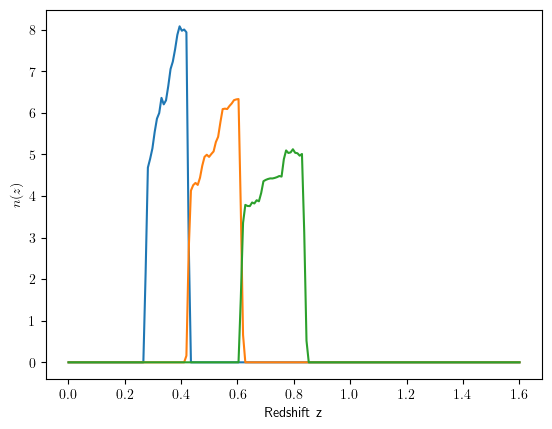

In [5]:
# analysis_dict['nbar_lens_bins']
# zmin, zmax
pl.figure()
for jz in range(nbins_lens):
    pl.plot(zarray_lens, nz_lens[jz], label=f'Lens bin {jz}')
# pl.plot(zarray_lens, nbar_array, label=f'Lens bin {jz}')
pl.xlabel('Redshift z')
pl.ylabel(r'$n(z)$')


Text(0, 0.5, '$n(z)$')

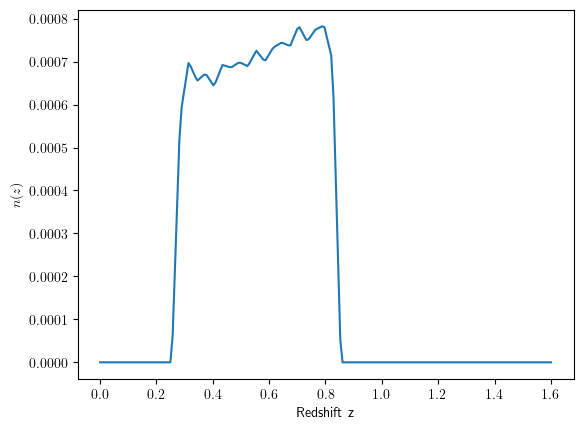

In [6]:
# analysis_dict['nbar_lens_bins']
# zmin, zmax
pl.figure()
# for jz in range(nbins_lens):
    # pl.plot(zarray_lens, nz_comoving_all[jz], label=f'Lens bin {jz}')
pl.plot(zarray_lens, nbar_array, label=f'Lens bin {jz}')
pl.xlabel('Redshift z')
pl.ylabel(r'$n(z)$')


In [7]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
import matplotlib.pyplot as pl


# sim_params_dict['log10M1_fshmr'] = 13.0
# sim_params_dict['delta_fshmr'] = 1.0
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)



In [8]:
df_sims = pk.load(open(os.path.abspath(abs_path_data + '/xDESI/abacus_LRG_nz_Clgg_v2.pkl'), 'rb'))
# df_data.keys()
Cls_sims = df_sims['Cl_gg_all']
# Cls_measure.keys()
l_array_sims = jnp.array(Cls_sims['l_array'][1:])
Cl_gg_sims0 = jnp.array(Cls_sims['z0.300_0.400'][1:])
Cl_gg_sims1 = jnp.array(Cls_sims['z0.450_0.575'][1:])
Cl_gg_sims2 = jnp.array(Cls_sims['z0.650_0.800'][1:])



In [9]:
data_vec = jnp.concatenate((Cl_gg_sims0, Cl_gg_sims1, Cl_gg_sims2), axis=0)

arcmin_to_rad = (1.0/60.0) * (np.pi/180.0)
nbar_inv_noise = 1/(analysis_dict['nbar_lens_bins'] / (arcmin_to_rad**2))
dl_array_sims = l_array_sims[1] - l_array_sims[0]
Cl_gg_sig_sims0 = jnp.sqrt(2.0/( (2.0 * l_array_sims + 1.0) * analysis_dict['fsky_gg'] * dl_array_sims)) * (Cl_gg_sims0 + nbar_inv_noise[0])
Cl_gg_sig_sims1 = jnp.sqrt(2.0/( (2.0 * l_array_sims + 1.0) * analysis_dict['fsky_gg'] * dl_array_sims)) * (Cl_gg_sims1 + nbar_inv_noise[1])
Cl_gg_sig_sims2 = jnp.sqrt(2.0/( (2.0 * l_array_sims + 1.0) * analysis_dict['fsky_gg'] * dl_array_sims)) * (Cl_gg_sims2 + nbar_inv_noise[2])

Cl_gg_sig_sims = jnp.concatenate((Cl_gg_sig_sims0, Cl_gg_sig_sims1, Cl_gg_sig_sims2), axis=0)
Cl_gg_cov_sims = jnp.diag(Cl_gg_sig_sims**2)

sigma_value_combined = 0.1 * data_vec
cov_total = jnp.diag(sigma_value_combined**2)
# Cl_gg_cov_sims = jnp.diag(Cl_gg_sig_sims**2)


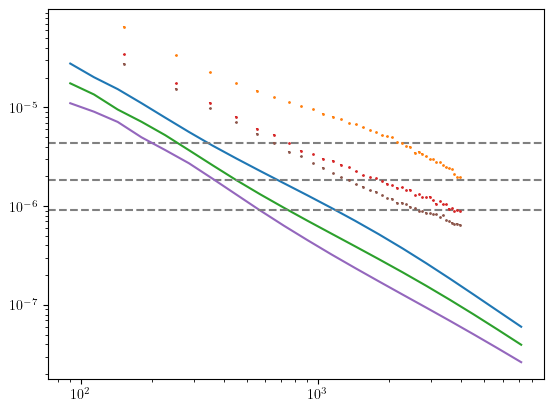

In [10]:
arcmin_to_rad = (1.0/60.0) * (np.pi/180.0)
nbar_inv_noise = 1/(analysis_dict['nbar_lens_bins'] / (arcmin_to_rad**2))
pl.figure
pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0])
pl.errorbar(l_array_sims, Cl_gg_sims0, yerr=Cl_gg_sig_sims0, fmt='o', ms=1)
pl.axhline(nbar_inv_noise[0], color='gray', linestyle='--')


pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,1,1])
pl.errorbar(l_array_sims, Cl_gg_sims1, yerr=Cl_gg_sig_sims1, fmt='o', ms=1)
pl.axhline(nbar_inv_noise[1], color='gray', linestyle='--')

pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,2,2])
pl.errorbar(l_array_sims, Cl_gg_sims2, yerr=Cl_gg_sig_sims2, fmt='o', ms=1)
pl.axhline(nbar_inv_noise[2], color='gray', linestyle='--')

pl.xscale('log')
pl.yscale('log')




In [11]:
# Cls_test.Cl_gal_gal_tot_mat


In [12]:
with open(abs_path_params + '/xDESI/priors_fit_abacus.yaml', 'r') as file:
    data = yaml.safe_load(file)
prior_limits = {key: tuple(map(float, value.split())) for key, value in data['prior_uniform'].items()}

prior_min_all_dict, prior_max_all_dict = {}, {}
for key in prior_limits.keys():
    prior_min_all_dict[key] = prior_limits[key][0]
    prior_max_all_dict[key] = prior_limits[key][1]

sims_params_vary_names = list(prior_min_all_dict.keys())


In [13]:
import jax 
from tqdm import tqdm
import copy
import numpyro
import copy

def model():
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)

    if len(sims_params_vary_names) > 0:
        for jp in range(len(sims_params_vary_names)):
            prior_min_jp = prior_min_all_dict[sims_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[sims_params_vary_names[jp]]
            sim_params_dict_vary[sims_params_vary_names[jp]] = Uniform(sims_params_vary_names[jp], prior_min_jp, prior_max_jp)
        
    base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

    nell = len(l_array_sims)
    mu = jnp.zeros(len(data_vec))
    for jp1 in range(analysis_dict['nz_lens_info_dict']['nbins_lens']):
        theory_val_jp1 = get_power_BCMP_test.Cl_gal_gal_tot_mat[:,jp1,jp1]
        theory_val = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(get_power_BCMP_test.ell_array), jnp.log(jnp.nan_to_num(theory_val_jp1) + 1e-20)))
        mu = mu.at[jp1*nell:(jp1+1)*nell].set(theory_val)

    return numpyro.sample('cl', dist.MultivariateNormal(mu, 
                                                            # precision_matrix=P_total,
                                                            covariance_matrix=cov_total
                                                            ))




/u/spandey3/.conda/envs/gdmf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import numpyro
numpyro.set_host_device_count(4)
from numpyro.handlers import seed, trace, condition
# Now we condition the model on obervations
observed_model = condition(model, {'cl': data_vec})

import numpyro
from numpyro.infer.reparam import LocScaleReparam, TransformReparam

def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None

observed_model_reparam = numpyro.handlers.reparam(observed_model, config=config)



In [15]:
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )



In [16]:
# from numpyro.contrib.nested_sampling import NestedSampler
# ns = NestedSampler(observed_model_reparam, constructor_kwargs={"num_live_points": 20}, termination_kwargs={"max_samples": 20})
# rng_key = jax.random.PRNGKey(42)
# ns.run(rng_key)


In [17]:
# samples = ns.get_samples(rng_key, num_samples=100)



In [18]:
# samples

In [19]:
# from numpyro.infer import HMC, HMCECS, MCMC, ESS, NUTS, SA, SVI, Trace_ELBO, init_to_value
# num_warmup = 20
# num_samples = 20
# n_vectorized = 16
# rng_key = jax.random.PRNGKey(42)
# nuts_kernel = numpyro.infer.ESS(observed_model_reparam,
#                             # step_size=2e-1, 
#                             moves={ESS.DifferentialMove() : 0.8, ESS.RandomMove() : 0.2},
#                             init_strategy=numpyro.infer.init_to_median,
#                             # dense_mass=True,
#                             # max_tree_depth=4
#                             # forward_mode_differentiation=True
#                             )

# mcmc = numpyro.infer.MCMC(nuts_kernel, 
#                         num_warmup=num_warmup, 
#                         num_samples=num_samples,
#                         num_chains=n_vectorized,
#                         chain_method='vectorized',
#                         #   chain_method='sequential',                          
#                         progress_bar=True,
#                         jit_model_args=True)

# mcmc.run(
#     rng_key
#     # extra_fields=("potential_energy",),
# )




In [20]:
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
num_warmup = 800
num_samples = 1200
n_vectorized = 24
rng_key = jax.random.PRNGKey(42)
nuts_kernel = numpyro.infer.NUTS(observed_model_reparam,
                            step_size=2e-1, 
                            init_strategy=numpyro.infer.init_to_median,
                            dense_mass=True,
                            max_tree_depth=4
                            # forward_mode_differentiation=True
                            )

mcmc = numpyro.infer.MCMC(nuts_kernel, 
                        num_warmup=num_warmup, 
                        num_samples=num_samples,
                        num_chains=n_vectorized,
                        chain_method='vectorized',
                        #   chain_method='sequential',                          
                        progress_bar=True,
                        jit_model_args=True)

mcmc.run(
    rng_key,
    extra_fields=("potential_energy",),
)




sample: 100%|██████████| 2000/2000 [11:53<00:00,  2.80it/s]


(28800, 14) 14
Removed no burn in


<Figure size 1425x1425 with 0 Axes>

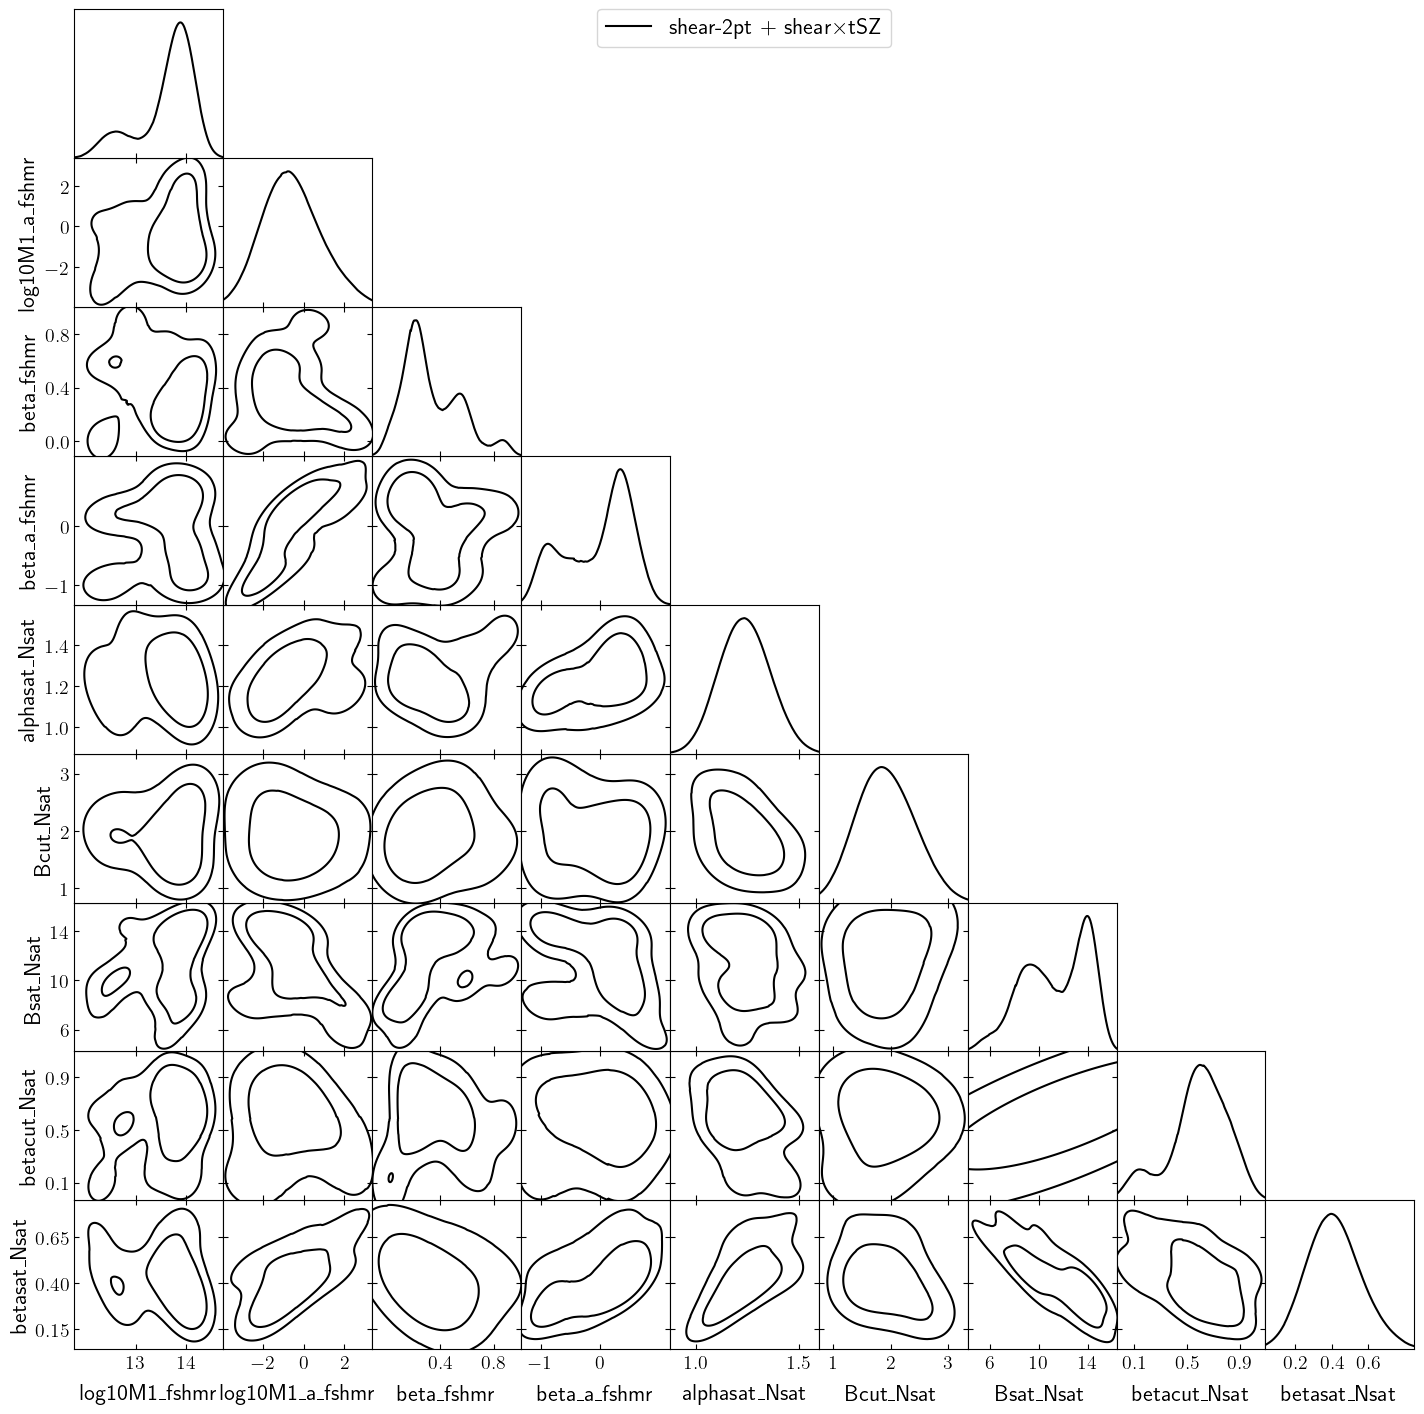

In [21]:
samps_all_dict = mcmc.get_samples()
import pickle as pk

samps = []
keys = []
for key in samps_all_dict:
    if ('base' not in key) and ('decentered' not in key):
        # print(key, samps_all_dict[key].shape, len(samps_all_dict[key].shape))
        if len(samps) == 0:
            samps = samps_all_dict[key][:, None]
        else:
            if len(samps_all_dict[key].shape) > 1:
                samps = np.concatenate((samps, samps_all_dict[key]), axis=1)
            else:
                samps = np.concatenate((samps, samps_all_dict[key][:, None]), axis=1)
        if 'array' in key:
            for jb in range(samps_all_dict[key].shape[1]):
                keys.append(key + str(jb))
        else:
            keys.append(key)
samps = np.array(samps)

samps = np.array(samps)
import getdist
from getdist import plots, MCSamples
# names = ["x%s"%i for i in range(ndim)]
# labels =  ["x_%s"%i for i in range(ndim)]
names = keys
# labels = keys
print(samps.shape, len(names))
samples = MCSamples(samples=samps,names = names)

g = plots.getSinglePlotter(width_inch=14.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}

params = samples.getParamNames().getRunningNames()
g.triangle_plot([samples], ['log10M1_fshmr', 'log10M1_a_fshmr', 
                # 'delta_fshmr', 'delta_a_fshmr', 'gamma_fshmr', 'gamma_a_fshmr', 'siglogMstar_Ncen',
                'beta_fshmr', 'beta_a_fshmr', 'alphasat_Nsat', 
                'Bcut_Nsat', 'Bsat_Nsat', 'betacut_Nsat', 'betasat_Nsat'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'shear-2pt + shear$\times$tSZ',r'shear$\times$tSZ only',r'shear-2pt only'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()






In [22]:
# names
# samps_all_dict.keys()
chi2 = mcmc.get_extra_fields()['potential_energy']


In [23]:
# samps.shape
# names_array = ['log10M1_fshmr', 'log10M1_a_fshmr', 'delta_fshmr', 'delta_a_fshmr', 'gamma_fshmr', 'gamma_a_fshmr', 'siglogMstar_Ncen', 'alphasat_Nsat']
# xmin = []
# for name in names_array:
#     indsel = names.index(name)
#     xmin.append(np.median(samps[:, indsel]))

names_array = ['log10M1_fshmr', 'log10M1_a_fshmr', 
                # 'delta_fshmr', 'delta_a_fshmr', 'gamma_fshmr', 'gamma_a_fshmr', 'siglogMstar_Ncen',
                'beta_fshmr', 'beta_a_fshmr', 'alphasat_Nsat', 
                'Bcut_Nsat', 'Bsat_Nsat', 'betacut_Nsat', 'betasat_Nsat']
xmin = []
indmin = np.argmin(chi2)
for name in names_array:
    indsel = names.index(name)
    # xmin.append(np.median(samps[:, indsel]))
    xmin.append((samps[indmin, indsel]))
    print(name, samps[indmin, indsel])

    

log10M1_fshmr 14.031897439454504
log10M1_a_fshmr 0.5334867575468163
beta_fshmr 0.22640837852597917
beta_a_fshmr 0.5221660914054814
alphasat_Nsat 1.2622775783818976
Bcut_Nsat 2.5849448186462687
Bsat_Nsat 10.417958778712148
betacut_Nsat 0.562857073927527
betasat_Nsat 0.4436726075970492


In [24]:
params_vary_names = list(prior_min_all_dict.keys())
lower_bounds_dict = prior_min_all_dict
upper_bounds_dict = prior_max_all_dict

def get_value(x, return_model=False):

    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    
    for jp in range(len(sims_params_vary_names)):
        sim_params_dict_vary[sims_params_vary_names[jp]] = x[jp]

    base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

    # get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)

    nell = len(l_array_sims)
    theory_combined = jnp.zeros(len(data_vec))
    for jp1 in range(analysis_dict['nz_lens_info_dict']['nbins_lens']):
        theory_val_jp1 = get_power_BCMP_test.Cl_gal_gal_tot_mat[:,jp1,jp1]
        theory_val = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(get_power_BCMP_test.ell_array), jnp.log(theory_val_jp1)))
        theory_combined = theory_combined.at[jp1*nell:(jp1+1)*nell].set(theory_val)
    chi2 = jnp.sqrt(jnp.sum((theory_combined - data_vec)**2 / sigma_value_combined**2))
    if return_model:
        return chi2, get_power_BCMP_test
    else:
        return chi2



In [25]:
# with open(abs_path_params + '/xDESI/priors_fit_abacus.yaml', 'r') as file:
#     data = yaml.safe_load(file)
# prior_limits = {key: tuple(map(float, value.split())) for key, value in data['prior_uniform'].items()}

# prior_min_all_dict, prior_max_all_dict = {}, {}
# for key in prior_limits.keys():
#     prior_min_all_dict[key] = prior_limits[key][0]
#     prior_max_all_dict[key] = prior_limits[key][1]

# sims_params_vary_names = list(prior_min_all_dict.keys())


# # w_init = []
# # for jp in range(len(sims_params_vary_names)):
# #     w_init.append(sim_params_dict[sims_params_vary_names[jp]])
# # w_init = jnp.array(w_init)

# w_init = jnp.array(xmin)

# # lbfgsb = ScipyBoundedMinimize(fun=get_value_and_grad, value_and_grad=True, method="l-bfgs-b", tol=1e-9, maxiter=200)
# lbfgsb = ScipyBoundedMinimize(fun=get_value, value_and_grad=False, method="l-bfgs-b", tol=1e-9, maxiter=200)

# lower_bounds = []
# upper_bounds = []
# for jp in range(len(sims_params_vary_names)):
#     lower_bounds.append(prior_min_all_dict[sims_params_vary_names[jp]])
#     upper_bounds.append(prior_max_all_dict[sims_params_vary_names[jp]])

# lower_bounds = jnp.array(lower_bounds)
# upper_bounds = jnp.array(upper_bounds)

# bounds = (lower_bounds, upper_bounds)
# res = lbfgsb.run(w_init, bounds=bounds)






In [26]:
# res[0], res[1]
# xmin_min = res[0]



In [27]:
# chi2
# ind_min = np.argmin(chi2)
chi2_good, model_good = get_value(xmin, return_model=True)



IndexError: list index out of range

In [ ]:
# chi2
# ind_min = np.argmin(chi2)
# chi2, model_best = get_value(xmin_min, return_model=True)



In [ ]:
# chi2, chi2_good
chi2_good


Array(10.92890911, dtype=float64)

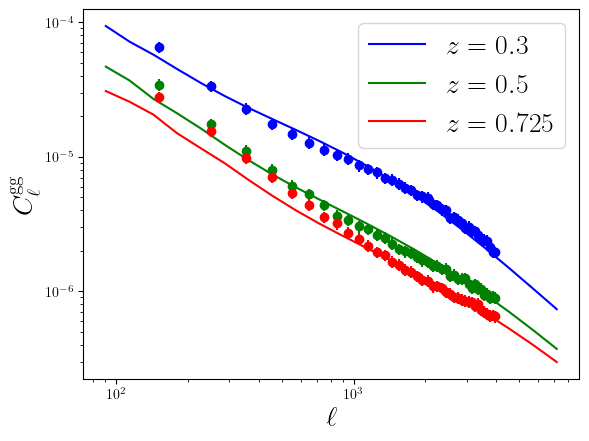

In [ ]:
# Cls_test.Cl_gal_gal_tot_mat.shape

colors = ['blue', 'green', 'red']
pl.figure
pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,0,0], color=colors[0], label=r'$z=0.3$')
pl.errorbar(l_array_sims, Cl_gg_sims0, yerr=0.1*Cl_gg_sims0, fmt='o', color=colors[0])
pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,1,1], color=colors[1], label=r'$z=0.5$')
pl.errorbar(l_array_sims, Cl_gg_sims1, yerr=0.1*Cl_gg_sims1, fmt='o', color=colors[1])
pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,2,2], color=colors[2], label=r'$z=0.725$')
pl.errorbar(l_array_sims, Cl_gg_sims2, yerr=0.1*Cl_gg_sims2, fmt='o', color=colors[2])
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
pl.legend(fontsize=20)



In [88]:
# Cls_test.Cl_gal_gal_tot_mat.shape

colors = ['blue', 'green', 'red']
pl.figure
pl.plot(Cls_test.ell_array, model_best.Cl_gal_gal_tot_mat[:,0,0], color=colors[0], label=r'$z=0.3$')
pl.errorbar(l_array_sims, Cl_gg_sims0, yerr=0.1*Cl_gg_sims0, fmt='o', color=colors[0])
pl.plot(Cls_test.ell_array, model_best.Cl_gal_gal_tot_mat[:,1,1], color=colors[1], label=r'$z=0.5$')
pl.errorbar(l_array_sims, Cl_gg_sims1, yerr=0.1*Cl_gg_sims1, fmt='o', color=colors[1])
pl.plot(Cls_test.ell_array, model_best.Cl_gal_gal_tot_mat[:,2,2], color=colors[2], label=r'$z=0.725$')
pl.errorbar(l_array_sims, Cl_gg_sims2, yerr=0.1*Cl_gg_sims2, fmt='o', color=colors[2])
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
pl.legend(fontsize=20)



NameError: name 'model_best' is not defined

In [95]:
params_vary_names = list(prior_min_all_dict.keys())
lower_bounds_dict = prior_min_all_dict
upper_bounds_dict = prior_max_all_dict

def get_value(x):

    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    
    for jp in range(len(sims_params_vary_names)):
        sim_params_dict_vary[sims_params_vary_names[jp]] = x[jp]

    base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

    # get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)

    nell = len(l_array_sims)
    theory_combined = jnp.zeros(len(data_vec))
    for jp1 in range(analysis_dict['nz_lens_info_dict']['nbins_lens']):
        theory_val_jp1 = get_power_BCMP_test.Cl_gal_gal_tot_mat[:,jp1,jp1]
        theory_val = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(get_power_BCMP_test.ell_array), jnp.log(theory_val_jp1)))
        theory_combined = theory_combined.at[jp1*nell:(jp1+1)*nell].set(theory_val)
    chi2 = jnp.sqrt(jnp.sum((theory_combined - data_vec)**2 / sigma_value_combined**2))

    return chi2


def get_value_and_grad(x):
    value, grad = value_and_grad(get_value)(x)
    value = jnp.nan_to_num(value, nan=1e20, posinf=1e20, neginf=1e20)
    grad = jnp.nan_to_num(grad, nan=-1e20, posinf=0.0, neginf=0.0)
    return value, grad


In [96]:
with open(abs_path_params + '/xDESI/priors_fit_abacus.yaml', 'r') as file:
    data = yaml.safe_load(file)
prior_limits = {key: tuple(map(float, value.split())) for key, value in data['prior_uniform'].items()}

prior_min_all_dict, prior_max_all_dict = {}, {}
for key in prior_limits.keys():
    prior_min_all_dict[key] = prior_limits[key][0]
    prior_max_all_dict[key] = prior_limits[key][1]

sims_params_vary_names = list(prior_min_all_dict.keys())


In [97]:
sims_params_vary_names
# x_fid = []
# for jp in range(len(params_vary_names)):
#     x_fid.append(sim_params_dict[params_vary_names[jp]])
# x_fid = jnp.array(x_fid)
# print(x_fid)


['log10M1_fshmr',
 'log10M1_a_fshmr',
 'delta_fshmr',
 'delta_a_fshmr',
 'gamma_fshmr',
 'gamma_a_fshmr',
 'siglogMstar_Ncen',
 'alphasat_Nsat']

In [98]:
# # Cls_test.Cl_gal_gal_tot_mat.shape

# pl.figure
# pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0])
# pl.errorbar(l_array_sims, Cl_gg_sims0, yerr=0.05*Cl_gg_sims0, fmt='o')
# pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,1,1])
# pl.errorbar(l_array_sims, Cl_gg_sims1, yerr=0.05*Cl_gg_sims1, fmt='o')
# pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,2,2])
# pl.errorbar(l_array_sims, Cl_gg_sims2, yerr=0.05*Cl_gg_sims2, fmt='o')
# pl.xscale('log')
# pl.yscale('log')






In [99]:
x_fid = jnp.array([12.95, 1.0, 0.25, 0.1, 0.1, 0.1, 0.5, 1.4])
# x_fid = jnp.array([0.5])
value_and_grad(get_value)(x_fid)
# # get_value(x_fid)
# get_value_and_grad(x_fid)




(Array(77.48322482, dtype=float64),
 Array([nan, nan, nan, nan, nan, nan, nan, nan], dtype=float64))

In [63]:
x = x_fid
sim_params_dict_vary = copy.deepcopy(sim_params_dict)

for jp in range(len(sims_params_vary_names)):
    sim_params_dict_vary[sims_params_vary_names[jp]] = x[jp]

base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)




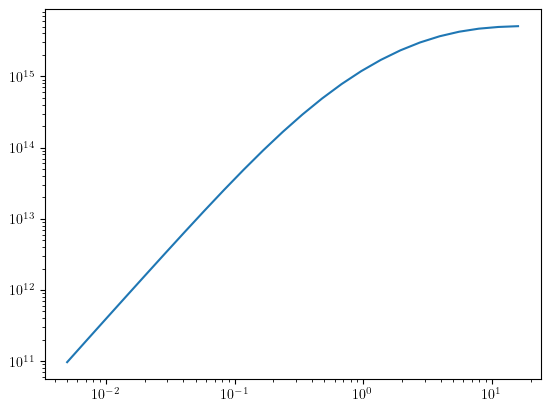

In [ ]:
pl.figure()
pl.plot(profiles_test.r_array, profiles_test.Mclm_mat[:,0,-1])
pl.xscale('log')
pl.yscale('log')



In [33]:
w_init = []
for jp in range(len(sims_params_vary_names)):
    w_init.append(sim_params_dict[sims_params_vary_names[jp]])
w_init = jnp.array(w_init)

# lbfgsb = ScipyBoundedMinimize(fun=get_value_and_grad, value_and_grad=True, method="l-bfgs-b", tol=1e-9, maxiter=200)
lbfgsb = ScipyBoundedMinimize(fun=get_value, value_and_grad=False, method="l-bfgs-b", tol=1e-9, maxiter=200)

lower_bounds = []
upper_bounds = []
for jp in range(len(sims_params_vary_names)):
    lower_bounds.append(prior_min_all_dict[sims_params_vary_names[jp]])
    upper_bounds.append(prior_max_all_dict[sims_params_vary_names[jp]])

lower_bounds = jnp.array(lower_bounds)
upper_bounds = jnp.array(upper_bounds)

bounds = (lower_bounds, upper_bounds)
res = lbfgsb.run(w_init, bounds=bounds)




In [37]:
res[0], res[1]




(Array([12.55,  0.38,  0.37,  0.21,  1.79, -0.72,  0.7 ,  1.19], dtype=float64),
 ScipyMinimizeInfo(fun_val=Array(nan, dtype=float64, weak_type=True), success=False, status=2, iter_num=0, hess_inv=LbfgsInvHessProduct(sk=[], yk=[]), num_fun_eval=Array(21, dtype=int32), num_jac_eval=Array(21, dtype=int32), num_hess_eval=Array(0, dtype=int32)))

In [36]:
get_value(res[0])




Array(155.59566072, dtype=float64)